---
<center>

### Université de Caen Normandie

## Projet Apprentissage Profond Avancé

---


# **Classification de Pneumonies par Radiographie Thoracique**

---

**Réalisé par :**

Ba BINTOU

Année universitaire : 2025-2026

---

</center>


## **Plan**

**Partie 1 : Introduction**
- Objectif du projet
- Description du projet

**Partie 2 : Pré-traitement des données**
- Dataset
- Description des données
- Répartition des données

**Partie 3 : Construction et entraînement des modèles**
- Architecture Xception
- Architecture ResNet50
- Entraînement

**Partie 4 : Évaluation et résultats**
- Résultats du modèle Xception
- Résultats du modèle ResNet50
- Comparaison des deux modèles

**Partie 5 : Conclusion**

# **Partie 1: Introduction**


### 1.2.2 **Objectif du projet**
Ce projet propose le développement d’un système d’aide au diagnostic basé sur le deep learning pour l’analyse automatique des radiographies thoraciques. L’objectif est de distinguer rapidement la pneumonie bactérienne de la pneumonie virale.


### 1.2.3 **Description du projet**
La première étape de notre projet sera la sélection d’un jeu de données d’images de radiographies thoracique.
Ces données subiront ensuite des pré-traitements nécessaires pour le modèle de classification. Des techniques
d’apprentissage supervisé basé sur les réseaux de neurones convolutifs seront utilisées afin de donner la probabilité
qu’une image appartienne à une des trois classes (Normal- Virus- Bactérie).




## **Partie 2 : Pré-traitement des données**

### **2.1 Dataset**
La base d'images sur laquelle nous avons travaillé provient de Mendeley Data, un référentiel sécurisé basé sur le cloud où sont stockés des millions de datasets issus de plusieurs entrepôts spécialisés et pluridisciplinaires, privés et publics.  
Le dataset contient des radiographies pulmonaires d'enfants âgés de 1 à 5 ans, réalisées dans un cadre clinique normal.

### **2.2 Description des données**
Le dataset Chest X-Ray contient **5856 images**.  
Chaque image est classée dans une des trois catégories suivantes :
- bacteria
- virus
- normal

Chaque image est associée à un identifiant patient.

### **2.3 Répartition des données**
Les images sont réparties en :
- 5232 images pour l'entraînement  
- 624 images pour le test  

Chaque ensemble est ensuite divisé en cas normaux et cas de pneumonie (bactérien et viral).

# **Importations des librairies**

In [1]:
import os
from imutils import paths
import random
import cv2
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers import Dense, MaxPool2D, Conv2D, BatchNormalization
from keras.layers import Input, Activation, MaxPooling2D
from keras.models import Model, Sequential
from keras.callbacks import CSVLogger, ReduceLROnPlateau, EarlyStopping
from keras.applications.inception_v3 import preprocess_input
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import datetime
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import classification_report


# **PATHS**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Chemin vers le dossier contenant les données d'entraînement
Train_path = '/content/drive/MyDrive/Pneumonia/NewData/Train/'

# Chemin vers le dossier contenant les données de test
Test_path = '/content/drive/MyDrive/Pneumonia/NewData/Test/'

# Dossier où les modèles entraînés seront sauvegardés
model_save_dir = "/content/drive/My Drive/Pneumonia/models/"

# Dossier de logs TensorBoard pour le modèle VGG
vgg_logs = '/content/drive/My Drive/Pneumonia/result/logs/vgg/'

# Dossier de logs TensorBoard pour le modèle InceptionV3
inception_logs = '/content/drive/My Drive/Pneumonia/result/logs/inceptionV3/'

# Dossier de logs TensorBoard pour le modèle ResNet
resnet_logs = '/content/drive/My Drive/Pneumonia/result/logs/resnet/'

# Dossier principal regroupant tous les logs TensorBoard
tensor_board_logs = '/content/drive/My Drive/Pneumonia/result/logs/'

# Dossier racine du projet Pneumonia
save_dir = '/content/drive/MyDrive/Pneumonia/'

# Dossier de logs TensorBoard pour le modèle Xception
xception_logs = '/content/drive/My Drive/Pneumonia/result/logs/xception/'

# Dossier de logs TensorBoard pour le modèle Mini-Xception
mini_xception_logs = '/content/drive/My Drive/Pneumonia/result/logs/mini_exception/'

# Dossier de logs TensorBoard pour le modèle Xception personnalisé
custom_xception_logs = '/content/drive/My Drive/Pneumonia/result/logs/custom_model/'


##**Visulisation des données**

In [4]:

Data_path = '/content/drive/MyDrive/Pneumonia/NewData/'
Data_paths = ['Train', 'Test']
list_labels = ['bacteria', 'virus', 'normal']

def Dataset_table(Data_path, Data_paths, labels):
    rows = []

    for dataset in Data_paths:
        for label in labels:
            folder = os.path.join(Data_path, dataset, label)
            images = list(paths.list_images(folder))

            rows.append({
                "Dataset": dataset,
                "Classe": label.upper(),
                "Nombre d'images": len(images)
            })

    df = pd.DataFrame(rows)
    return df

df = Dataset_table(Data_path, Data_paths, list_labels)
df


,Dataset,Classe,Nombre d'images
0,Train,BACTERIA,2571
1,Train,VIRUS,1359
2,Train,NORMAL,1476
3,Test,BACTERIA,562
4,Test,VIRUS,316
5,Test,NORMAL,299


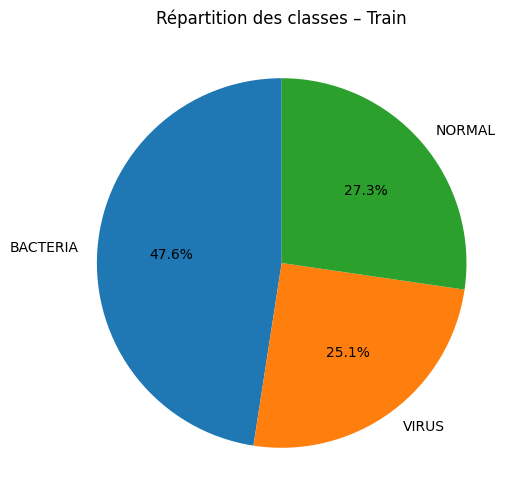

In [5]:
train_df = df[df["Dataset"] == "Train"]

plt.figure(figsize=(6,6))
plt.pie(
    train_df["Nombre d'images"],
    labels=train_df["Classe"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Répartition des classes – Train")
plt.show()


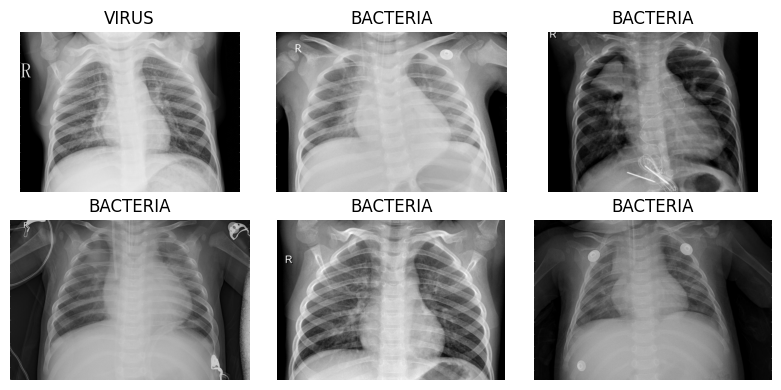

In [ ]:

Data_path = '/content/drive/MyDrive/Pneumonia/NewData/Train/'

# Récupére toutes les images
image_paths = list(paths.list_images(Data_path))

# Choisis 6 images au hasard
sample_paths = random.sample(image_paths, 6)

plt.figure(figsize=(8,4))

for i, img_path in enumerate(sample_paths):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    label = img_path.split(os.sep)[-2]  # bacteria / virus / normal

    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label.upper())
    plt.axis('off')

plt.tight_layout()
plt.show()


### **2.3 Normalisation des données**


La normalisation des pixels consiste à transformer ces valeurs vers l'intervalle [0, 1], ce qui rend les données plus homogènes et améliore la performance du modèle.
Dans notre dataset, certaines images contiennent une bordure noire due à la numérisation des radiographies, qui peut parfois occuper une grande partie de l'image.  
Pour ne conserver que les zones pertinentes, les images ont été redimensionnées en 224 × 224 pixels. En termes de pixels, les images sont en niveaux de gris (*grayscale*).  
Chaque pixel a une valeur comprise entre 0 et 255, où 0 correspond au noir et 255 correspond au blanc.  


### **2.4 Data Augmentation**

La Data Augmentation consiste à créer des variantes artificielles des images d'entraînement pour augmenter la diversité du dataset et éviter le surapprentissage (overfitting).  

Dans notre projet, plusieurs techniques ont été utilisées sur les images, notamment :  
- Rotation des images de quelques degrés  
- Zoom sur certaines zones  
- Translation (déplacement horizontal ou vertical)  
- Flip horizontal (miroir)  
- Modification de la luminosité  

Ces transformations permettent au modèle d'apprendre à reconnaître les mêmes caractéristiques, même si les images réelles sont légèrement différentes, ce qui améliore sa robustesse et sa généralisation.

In [7]:
def load_data(data_dir, targeted_labels=None, target_size=None):
  labels = []
  data = []
  image_paths = paths.list_images(data_dir)
  for image_path in image_paths:
    label = image_path.split(os.sep)[-2]
    if targeted_labels:
      if label not in targeted_labels :
        continue
    if target_size :
      img = cv2.resize(cv2.imread(image_path), target_size)
    else :
      img = cv2.imread(image_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    if img.any():
      data.append(img)
      labels.append(label)
    else :
      continue

  return data, labels

In [ ]:
# Chargement des données d'entraînement et de test
X_train, Y_train = load_data(Train_path, target_size=(224,224))
X_test, Y_test = load_data(Test_path, target_size=(224,224))


In [9]:
print("[INFO] Binirazing labels")
X_train = np.array(X_train)
X_test = np.array(X_test)

[INFO] Binirazing labels


In [10]:
X_train=np.expand_dims(X_train,axis=-1)
X_test=np.expand_dims(X_test,axis=-1)


In [ ]:
# Création d’un encodeur de labels en format binaire
lb = LabelBinarizer()

# Transformation des labels de test et d'entrainement en format binaire
Y_test = lb.fit_transform(Y_test)
Y_train = lb.fit_transform(Y_train)

In [12]:
X_train.shape



(5406, 224, 224, 1)

In [ ]:
# Générateur de données pour l'entraînement avec augmentation de données
train_datagen = ImageDataGenerator(
	rescale=1 / 255.0,
	rotation_range=20,
	zoom_range=0.05,
	width_shift_range=0.05,
	height_shift_range=0.05,
	shear_range=0.05,
	horizontal_flip=True,
	fill_mode="nearest")
test_datagen = ImageDataGenerator(rescale = 1/255)


In [ ]:
# Normalisation X_test
X_test_normalized = X_test / 255.0

print(f"Avant : Min={X_test.min()}, Max={X_test.max()}")
print(f"Après : Min={X_test_normalized.min()}, Max={X_test_normalized.max()}")

Avant : Min=0, Max=255
Après : Min=0.0, Max=1.0


#**Partie 3: Modélisation**

Les modèles ont été entraîné sur **60 époques** avec un **batch size de 32**.







In [15]:
batch_size = 32
epochs = 60

### **Callbacks utilisés**

**ReduceLROnPlateau** : Réduit automatiquement le learning rate de 68% si le modèle stagne pendant 5 époques, pour affiner l'apprentissage.

**EarlyStopping** : Arrête l'entraînement si la performance ne s'améliore pas pendant 20 époques, pour éviter de perdre du temps.

In [16]:
lr_reducer = ReduceLROnPlateau(factor=np.sqrt(0.1), cooldown=0, patience=5, min_lr=0.5e-4)
early_stopper = EarlyStopping(min_delta=0.001, patience=20)

### **3.1 L'approche utilisée**

Le **transfert learning** (apprentissage par transfert) est une technique qui consiste à utiliser un modèle pré-entraîné sur un autre dataset pour résoudre une nouvelle tâche.  
Cela permet souvent de gagner du temps et d'améliorer les performances, car le modèle a déjà appris à extraire des caractéristiques utiles à partir d'images.

Dans notre projet :
- mais nous n'utilisons pas leurs poids pré-entraînés.  
- À la place, le modèle est initialisé avec des poids aléatoires et entraîné à partir de zéro sur notre dataset.

### **3.2 Architecture Xception**

L'architecture Xception a été proposée par François Chollet, le créateur de Keras.  
Xception est une extension d'Inception qui utilise des **convolutions séparables en profondeur** (depthwise separable convolutions).
Cette technique sépare l'apprentissage spatial et l'apprentissage des canaux, ce qui rend le modèle plus efficace et capable d'extraire des caractéristiques fines des images médicales.
### **3.3 Architecture ResNet50**

ResNet50 a remporté ImageNet 2015. Les réseaux très profonds peuvent perdre en précision, mais ResNet50 utilise des **skip connections** pour sauter certaines couches et maintenir la performance.  
ResNet50 permet de construire des réseaux très profonds de manière stable grâce aux skip connections, tout en extrayant efficacement des caractéristiques complexes des images.

In [17]:
class architecture :
  @staticmethod
  def xception(input_shape, output_shape):
    from tensorflow.keras.applications import Xception
    from keras.layers import Input
    model = Xception(
      include_top=True,
      weights=None,
      input_tensor=None,
      input_shape=input_shape,
      pooling=None,
      classes=output_shape,
      classifier_activation="softmax",
  )
    return model
  def resnet_50(input_shape, output_shape):
    from tensorflow.keras.applications import ResNet50
    from keras.layers import Input
    resnet50_model = ResNet50(
      include_top=True,
      weights=None,
      input_tensor=None,
      input_shape=input_shape,
      pooling=None,
      classes=output_shape,
      classifier_activation="softmax",
  )
    resnet50_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return resnet50_model



### **Entraînement Xception**

In [18]:
models_history = {}

In [20]:
xception_model = architecture.xception((224,224,1), len(list_labels))
xception_model.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['accuracy'])
xception_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        288 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 20,867,051 (79.60 MB)

 Trainable params: 20,812,523 (79.39 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [21]:
log_dir = xception_logs + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
xception_history = xception_model.fit( train_datagen.flow(X_train, Y_train, batch_size=batch_size), epochs=epochs,
                                    validation_data=test_datagen.flow(X_test, Y_test, batch_size=batch_size),
                                     callbacks=[tensorboard_callback,lr_reducer,early_stopper])
models_history["xception"] = xception_history

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 157s 596ms/step - accuracy: 0.6636 - loss: 0.7778 - val_accuracy: 0.4775 - val_loss: 1.0780 - learning_rate: 0.0100
Epoch 2/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 125ms/step - accuracy: 0.7427 - loss: 0.6108 - val_accuracy: 0.4775 - val_loss: 1.0745 - learning_rate: 0.0100
Epoch 3/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - accuracy: 0.7683 - loss: 0.5514 - val_accuracy: 0.4775 - val_loss: 1.3188 - learning_rate: 0.0100
Epoch 4/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - accuracy: 0.7853 - loss: 0.5313 - val_accuracy: 0.4783 - val_loss: 1.6379 - learning_rate: 0.0100
Epoch 5/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - accuracy: 0.7873 - loss: 0.5105 - val_accuracy: 0.6882 - val_loss: 0.6689 - learning_rate: 0.0100
Epoch 6/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.7844 - loss: 0.5112 - val_accuracy: 0.7222 - val_loss: 0.7410 - learning_rate: 0.0100
Epoch 7/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - accuracy: 0.

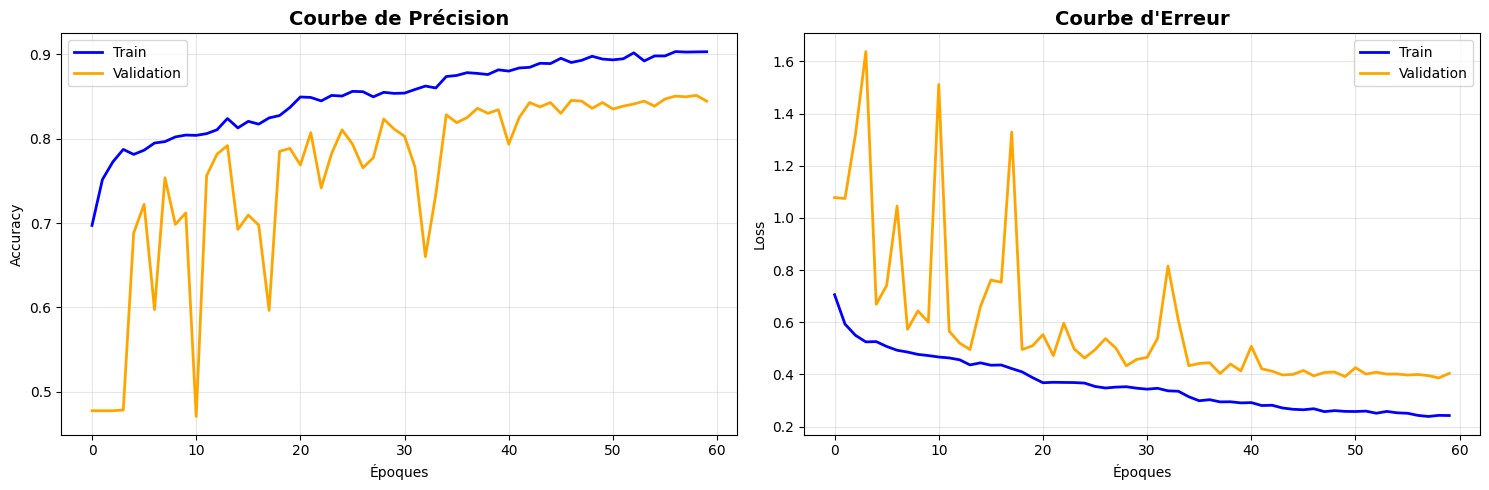

In [ ]:


# Extraction de l'historique
history = xception_history.history

# Création de 2 graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1 : Précision (Accuracy)
ax1.plot(history['accuracy'], label='Train', linewidth=2, color='blue')
ax1.plot(history['val_accuracy'], label='Validation', linewidth=2, color='orange')
ax1.set_title('Courbe de Précision', fontsize=14, fontweight='bold')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Erreur (Loss)
ax2.plot(history['loss'], label='Train', linewidth=2, color='blue')
ax2.plot(history['val_loss'], label='Validation', linewidth=2, color='orange')
ax2.set_title('Courbe d\'Erreur', fontsize=14, fontweight='bold')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Entraînement Resnet**

In [23]:
resnet_model = architecture.resnet_50((224,224,1), len(list_labels))
resnet_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      3,200 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,587 (89.98 MB)

 Trainable params: 23,534,467 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [24]:
log_dir = resnet_logs + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
resnet_history = resnet_model.fit( train_datagen.flow(X_train,Y_train, batch_size=batch_size), epochs=epochs,
                                    validation_data=test_datagen.flow(X_test,Y_test, batch_size=batch_size),
                                     callbacks=[tensorboard_callback,lr_reducer,early_stopper])
models_history["resnet50"] = resnet_history

Epoch 1/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 104s 309ms/step - accuracy: 0.6030 - loss: 1.3692 - val_accuracy: 0.4749 - val_loss: 2.7368 - learning_rate: 0.0010
Epoch 2/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 129ms/step - accuracy: 0.7240 - loss: 0.6526 - val_accuracy: 0.3738 - val_loss: 1.3619 - learning_rate: 0.0010
Epoch 3/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 128ms/step - accuracy: 0.7525 - loss: 0.5964 - val_accuracy: 0.6066 - val_loss: 0.9146 - learning_rate: 0.0010
Epoch 4/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 128ms/step - accuracy: 0.7532 - loss: 0.5976 - val_accuracy: 0.5879 - val_loss: 1.0581 - learning_rate: 0.0010
Epoch 5/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 129ms/step - accuracy: 0.7714 - loss: 0.5511 - val_accuracy: 0.7179 - val_loss: 0.6872 - learning_rate: 0.0010
Epoch 6/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 129ms/step - accuracy: 0.7788 - loss: 0.5465 - val_accuracy: 0.5132 - val_loss: 1.7597 - learning_rate: 0.0010
Epoch 7/60
169/169 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - accuracy: 0.

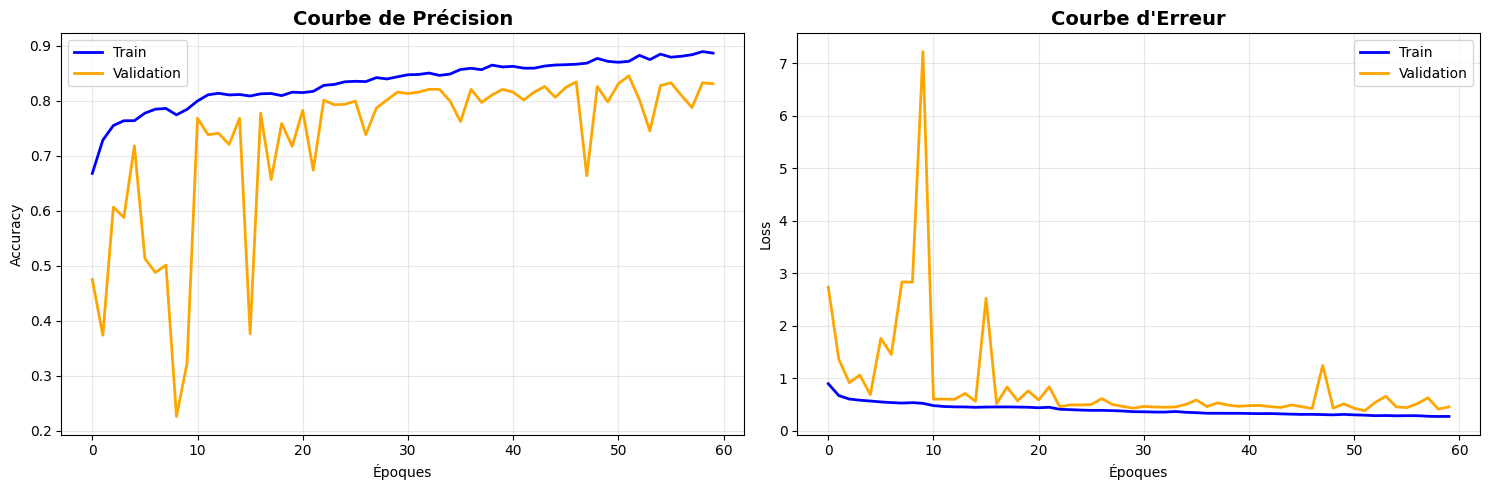

In [ ]:
# Extraction l'historique
history = resnet_history.history

# Création de 2 graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1 : Précision (Accuracy)
ax1.plot(history['accuracy'], label='Train', linewidth=2, color='blue')
ax1.plot(history['val_accuracy'], label='Validation', linewidth=2, color='orange')
ax1.set_title('Courbe de Précision', fontsize=14, fontweight='bold')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Erreur (Loss)
ax2.plot(history['loss'], label='Train', linewidth=2, color='blue')
ax2.plot(history['val_loss'], label='Validation', linewidth=2, color='orange')
ax2.set_title('Courbe d\'Erreur', fontsize=14, fontweight='bold')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Partie 4 : Évaluation et résultats**

In [43]:
def evaluate_model(classifier, valid_x, valid_Y, labels, batch_size=128):
    valid_y = valid_Y.argmax(axis=1)
    predictionss = classifier.predict(valid_x, batch_size=128)
    predictions = predictionss.argmax(axis=1)

    classification_rep = classification_report(valid_y,predictions, target_names=(labels))
    return (metrics.accuracy_score(valid_y, predictions), metrics.f1_score(valid_y, predictions, average='weighted'),
            metrics.recall_score(valid_y, predictions, average='weighted'), metrics.precision_score(valid_y, predictions, average='weighted'),
            metrics.confusion_matrix(valid_y, predictions), classification_rep)

In [ ]:
def result_vis_selected(result, l):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sn
    import numpy as np

    width = 0.2
    selected_models = ["xception", "resnet50"]  # les modèles pour lesquels on affiche la matrice
    labels = list(result.keys())

    accuracy = []
    f1_score = []
    recall = []
    precision = []

    for label in labels:
        print("[INFO] Metrics for:", label)
        print("Accuracy_______: ", result[label]['accuracy'])
        print("F1_score_______: ", result[label]['f1_score'])
        print("Recall_________: ", result[label]['recall'])
        print("Precision______: ", result[label]['precision'])
        print("Classification report:")
        print(result[label]['report'])

        # Affichage de la matrice de confusion uniquement pour Xception et ResNet
        if label.lower() in selected_models:
            df_cm = pd.DataFrame(result[label]["confusion_matrix"], index=l, columns=l)
            plt.figure(figsize=(8,6))
            sn.set(font_scale=1.2)
            sn.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", xticklabels=l, yticklabels=l)
            plt.title(f"Matrice de confusion: {label}")
            plt.ylabel("Vraies classes")
            plt.xlabel("Classes prédites")
            plt.show()

        accuracy.append(result[label]['accuracy'])
        f1_score.append(result[label]['f1_score'])
        recall.append(result[label]['recall'])
        precision.append(result[label]['precision'])

    # Graphe comparatif
    X = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8, 6))
    rect1 = ax.bar(X + 0.00, accuracy, width, label="accuracy")
    rect2 = ax.bar(X + 0.20, f1_score, width, label="f1_score")
    rect3 = ax.bar(X + 0.40, recall, width, label="recall")
    rect4 = ax.bar(X + 0.60, precision, width, label="precision")

    ax.set_ylabel("Scores")
    ax.set_title("Comparaison des métriques")
    ax.set_xticks(X + width, labels)
    ax.legend(loc="best")
    ax.set_ylim(0, 1)

    # Fonction pour afficher la valeur au-dessus de chaque barre
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f"{height:.2f}",
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center", va="bottom")

    autolabel(rect1)
    autolabel(rect2)
    autolabel(rect3)
    autolabel(rect4)
    plt.show()


## **Interprétation des résultats du modèle Xception**

In [45]:
result={}
metric = evaluate_model(xception_model, X_test_normalized, Y_test, list_labels)
result["xception"] = {"accuracy":round(metric[0],3),"f1_score":round(metric[1],3),"recall":round(metric[2],3),
                                  "precision":round(metric[3], 3), "confusion_matrix":metric[4], "report": metric[5]}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


[INFO] Metrics for: xception
Accuracy_______:  0.845
F1_score_______:  0.842
Recall_________:  0.845
Precision______:  0.842
Classification report:
              precision    recall  f1-score   support

    bacteria       0.87      0.86      0.86       562
       virus       0.89      0.98      0.93       299
      normal       0.75      0.70      0.72       316

    accuracy                           0.84      1177
   macro avg       0.84      0.84      0.84      1177
weighted avg       0.84      0.84      0.84      1177



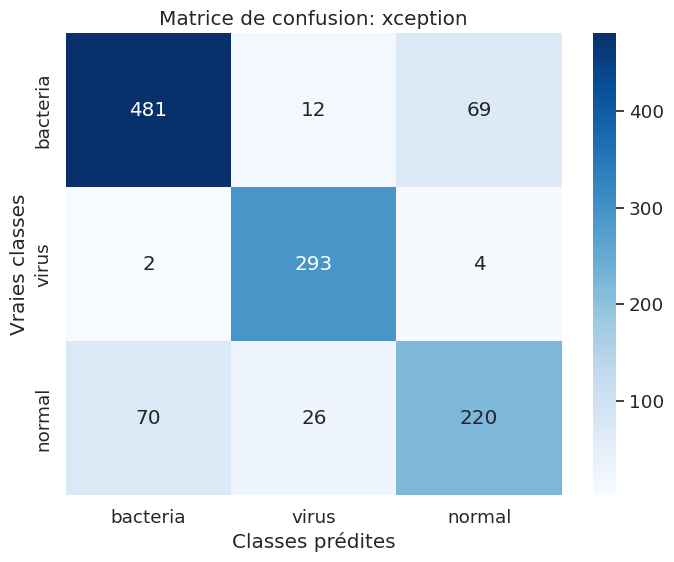

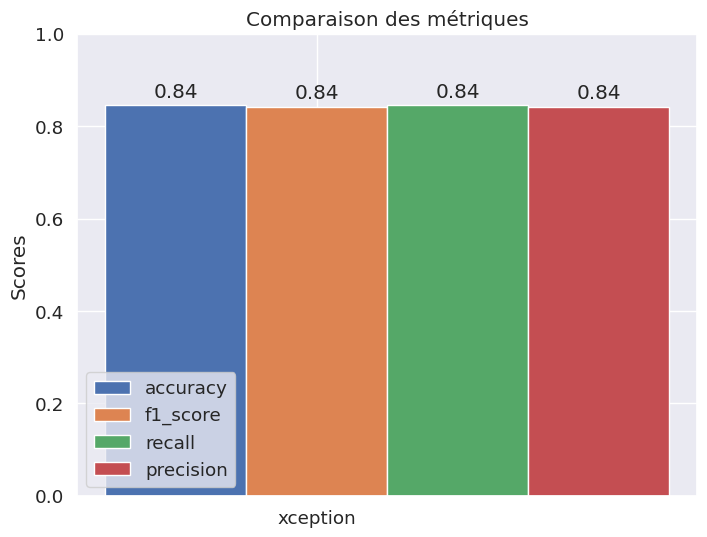

In [46]:
result_vis_selected(result, list_labels)

**Performances Globales**

Métrique     | Score  | Signification
-------------|--------|--------------------------------------------
Accuracy     | 84.5%  | Classe correctement 845 radiographies sur 1000
F1-score     | 84.2%  | Bon équilibre entre précision et détection
Recall       | 84.5%  | Détecte 84 cas de pneumonie sur 100
Precision    | 84.2%  | 84 diagnostics corrects sur 100 posés

**Performances par Classe**
Classe    | Precision | Recall | F1-score | Interprétation
----------|-----------|--------|----------|--------------------------------------------------
Bactéries | 87%       | 86%    | 86%      | Très bonne détection des pneumonies bactériennes
Virus     | 89%       | 98%    | 93%      | Excellente détection, presque aucun cas manqué
Normal    | 75%       | 70%    | 72%      | Performance correcte mais perfectible

##**Interprétation des résultats du modèle Resnet50**

In [50]:

metric = evaluate_model(resnet_model, X_test_normalized, Y_test, list_labels)
result["resnet50"] = {"accuracy":round(metric[0],3),"f1_score":round(metric[1],3),"recall":round(metric[2],3),
                      "precision":round(metric[3],3), "confusion_matrix":metric[4], "report": metric[5]}


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


[INFO] Metrics for: resnet50
Accuracy_______:  0.831
F1_score_______:  0.823
Recall_________:  0.831
Precision______:  0.837
Classification report:
              precision    recall  f1-score   support

    bacteria       0.78      0.94      0.85       562
       virus       0.98      0.93      0.95       299
      normal       0.81      0.54      0.65       316

    accuracy                           0.83      1177
   macro avg       0.86      0.80      0.82      1177
weighted avg       0.84      0.83      0.82      1177



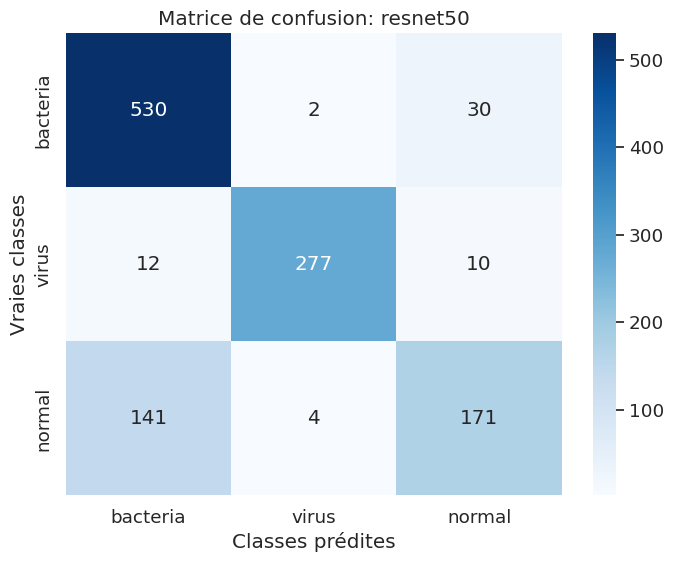

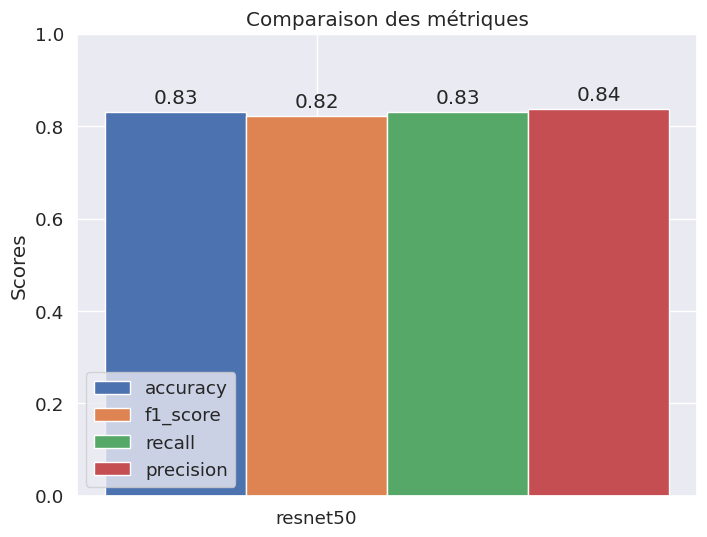

In [ ]:
# Création  d'un dictionnaire avec seulement ResNet
result_resnet_only = {"resnet50": result["resnet50"]}

# Affichage du ResNet
result_vis_selected(result_resnet_only, list_labels)

**Performances Globales**
Métrique     | Score  | Signification
-------------|--------|--------------------------------------------
Accuracy     | 83.1%  | Classe correctement 831 radiographies sur 1000
F1-score     | 82.3%  | Bon équilibre entre précision et détection
Recall       | 83.1%  | Détecte 83 cas de pneumonie sur 100
Precision    | 83.7%  | 84 diagnostics corrects sur 100 posés

**Performances par Classe**
Classe    | Precision | Recall | F1-score | Interprétation
----------|-----------|--------|----------|--------------------------------------------------
Bactéries | 78%       | 94%    | 85%      | Excellente détection, très peu de cas manqués
Virus     | 98%       | 93%    | 95%      | Performance exceptionnelle, très fiable
Normal    | 81%       | 54%    | 65%      | Point faible : confond poumons sains avec pneumonies

**CONCLUSION**

Xception obtient de meilleures performances globales (84.5% vs 83.1%), mais ResNet50 excelle pour détecter les pneumonies bactériennes (94% de recall) et virales (98% de précision). Le principal défaut de ResNet50 est son faible taux de détection des poumons sains (54%), conduisant à un sur-diagnostic. Pour un usage médical général, Xception est préférable grâce à son meilleur équilibre.

[INFO] Metrics for: xception
Accuracy_______:  0.845
F1_score_______:  0.842
Recall_________:  0.845
Precision______:  0.842
Classification report:
              precision    recall  f1-score   support

    bacteria       0.87      0.86      0.86       562
       virus       0.89      0.98      0.93       299
      normal       0.75      0.70      0.72       316

    accuracy                           0.84      1177
   macro avg       0.84      0.84      0.84      1177
weighted avg       0.84      0.84      0.84      1177



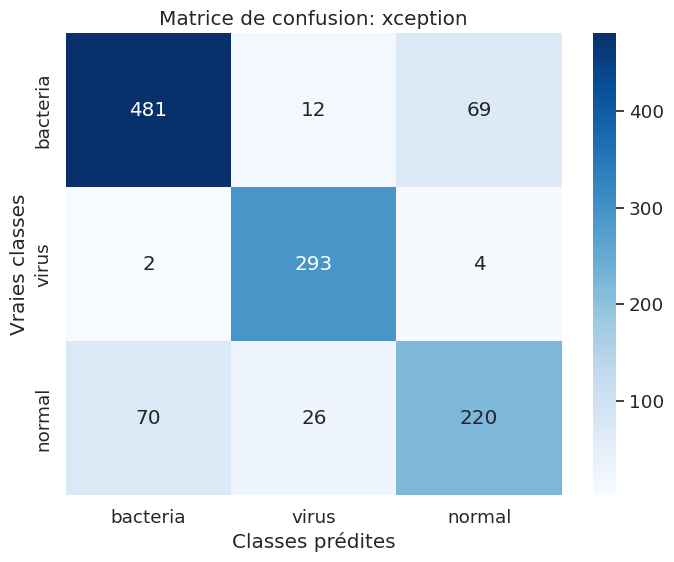

[INFO] Metrics for: resnet50
Accuracy_______:  0.831
F1_score_______:  0.823
Recall_________:  0.831
Precision______:  0.837
Classification report:
              precision    recall  f1-score   support

    bacteria       0.78      0.94      0.85       562
       virus       0.98      0.93      0.95       299
      normal       0.81      0.54      0.65       316

    accuracy                           0.83      1177
   macro avg       0.86      0.80      0.82      1177
weighted avg       0.84      0.83      0.82      1177



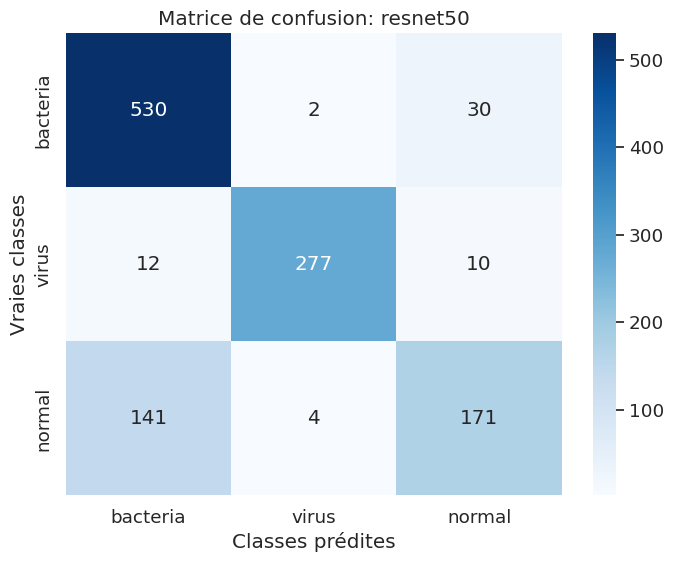

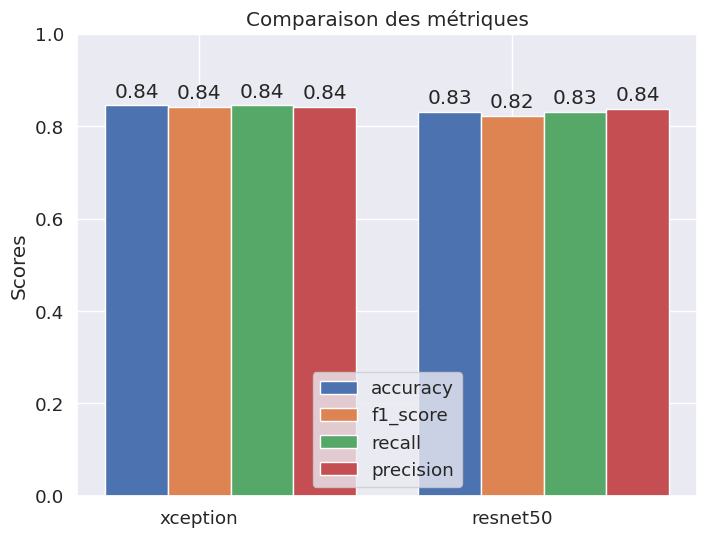

In [55]:
result_vis_selected(result, list_labels)  # Graphe de comparaison uniquement, sans matrices